# Modeling: PCA and Logistic Regression
## Predicting the outcome of a CS2 round from the freeze-time state


## 0. Setup


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.dummy import DummyClassifier

DATA_DIR = "../data/processed"
df_pistol      = pd.read_csv(f"{DATA_DIR}/df_pistol.csv")
df_post_pistol = pd.read_csv(f"{DATA_DIR}/df_post_pistol.csv")
df_normal      = pd.read_csv(f"{DATA_DIR}/df_normal.csv")

ct_color = "#1E3A6E"
t_color  = "#E8A020"


def create_delta(df, pairs, extra_cols):
    df_model = pd.DataFrame()
    for ct_col, t_col, delta_name in pairs:
        if ct_col in df.columns and t_col in df.columns:
            df_model[delta_name] = df[ct_col] - df[t_col]
    for col in extra_cols:
        if col in df.columns:
            df_model[col] = df[col]
    return df_model


extra_pistol      = ["round_number", "score_diff", "map_name", "round_winner", "ct_defuser_count"]
extra_post_pistol = ["round_number", "map_name", "ct_rounds_won_streak", "t_rounds_won_streak", "round_winner"]
extra_normal      = ["round_number", "map_name", "ct_rounds_won_streak", "t_rounds_won_streak", "ct_ak_count", "round_winner"]

grenade_pairs = [
    ("ct_smoke_count", "t_smoke_count", "delta_smoke_count"),
    ("ct_flash_count", "t_flash_count", "delta_flash_count"),
    ("ct_molo_count",  "t_molo_count",  "delta_molo_count"),
    ("ct_he_count",    "t_he_count",    "delta_he_count"),
]

pairs_pistol = [
    ("ct_equipment_value", "t_equipment_value", "delta_equipment_value"),
    ("ct_utility_value",   "t_utility_value",   "delta_utility_value"),
    ("ct_armor_count",     "t_armor_count",     "delta_armor_count"),
    ("ct_score",           "t_score",           "score_diff"),
] + grenade_pairs + [
    (f"ct_team_{s}_{w}_{m}", f"t_team_{s}_{w}_{m}", f"delta_{s}_{w}_{m}")
    for s in ("global", "map")
    for w in ("30d", "90d", "6months")
    for m in ("rating", "pistol_win_pct", "fa")
]

pairs_post_pistol = [
    ("ct_equipment_value",        "t_equipment_value",        "delta_equipment_value"),
    ("ct_utility_value",          "t_utility_value",          "delta_utility_value"),
    ("ct_rifle_count",            "t_rifle_count",            "delta_rifle_count"),
    ("ct_awp_count",              "t_awp_count",              "delta_awp_count"),
    ("ct_money_total",            "t_money_total",            "delta_money_total"),
    ("ct_armor_count",            "t_armor_count",            "delta_armor_count"),
    ("ct_helmet_count",           "t_helmet_count",           "delta_helmet_count"),
    ("ct_survivors_previous",     "t_survivors_previous",     "delta_survivors_previous"),
    ("ct_equipment_saved_value",  "t_equipment_saved_value",  "delta_equipment_saved_value"),
    ("ct_rounds_won_streak",      "t_rounds_won_streak",      "delta_rounds_won_streak"),
    ("ct_score",                  "t_score",                  "score_diff"),
] + grenade_pairs + [
    (f"ct_team_{s}_{w}_{m}", f"t_team_{s}_{w}_{m}", f"delta_{s}_{w}_{m}")
    for s in ("global", "map")
    for w in ("30d", "90d", "6months")
    for m in ("rating", "round2_conv", "round2_break", "fa")
]

pairs_normal = [
    ("ct_equipment_value",        "t_equipment_value",        "delta_equipment_value"),
    ("ct_utility_value",          "t_utility_value",          "delta_utility_value"),
    ("ct_rifle_count",            "t_rifle_count",            "delta_rifle_count"),
    ("ct_awp_count",              "t_awp_count",              "delta_awp_count"),
    ("ct_money_total",            "t_money_total",            "delta_money_total"),
    ("ct_armor_count",            "t_armor_count",            "delta_armor_count"),
    ("ct_helmet_count",           "t_helmet_count",           "delta_helmet_count"),
    ("ct_survivors_previous",     "t_survivors_previous",     "delta_survivors_previous"),
    ("ct_equipment_saved_value",  "t_equipment_saved_value",  "delta_equipment_saved_value"),
    ("ct_rounds_won_streak",      "t_rounds_won_streak",      "delta_rounds_won_streak"),
    ("ct_score",                  "t_score",                  "score_diff"),
] + grenade_pairs + [
    (f"ct_team_{s}_{w}_{m}", f"t_team_{s}_{w}_{m}", f"delta_{s}_{w}_{m}")
    for s in ("global", "map")
    for w in ("30d", "90d", "6months")
    for m in ("rating", "rw_pct", "adr", "fa")
]

df_pistol_delta      = create_delta(df_pistol,      pairs_pistol,      extra_pistol).dropna()
df_post_pistol_delta = create_delta(df_post_pistol, pairs_post_pistol, extra_post_pistol).dropna()
df_normal_delta      = create_delta(df_normal,      pairs_normal,      extra_normal).dropna()

print(f"df_pistol_delta      : {df_pistol_delta.shape}")
print(f"df_post_pistol_delta : {df_post_pistol_delta.shape}")
print(f"df_normal_delta      : {df_normal_delta.shape}")


df_pistol_delta      : (2945, 30)
df_post_pistol_delta : (2956, 44)
df_normal_delta      : (26322, 45)


## 1. Principal Component Analysis (PCA)


### 1.1 Pistol

### 1.1.1 Build the input dataframe

In [3]:
df_pistol_acp = df_pistol_delta.drop(columns=['round_winner', 'map_name']) 
feature_names_pistol = list(df_pistol_acp.columns) 

scaler = StandardScaler()
df_pistol_acp_scaled = scaler.fit_transform(df_pistol_acp)

print(f"df_pistol_acp : {df_pistol_acp.shape}")


df_pistol_acp : (2945, 28)


### 1.1.2 Scree plot and cumulative inertia

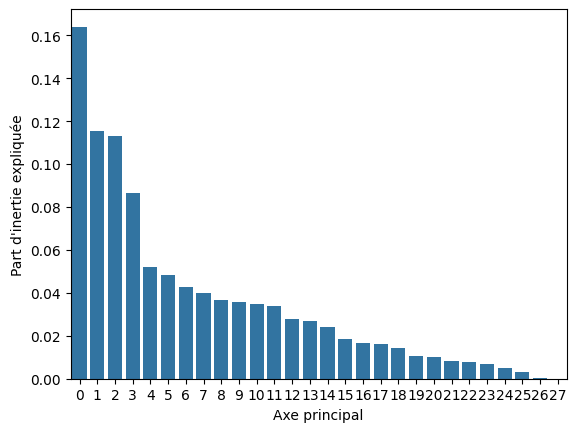

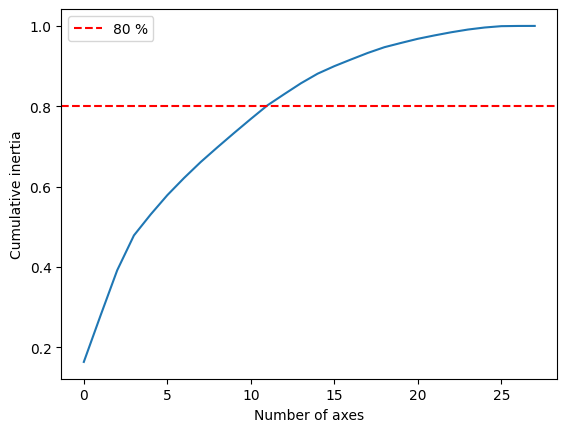

In [4]:
pca_pistol = PCA()
Z_pistol   = pca_pistol.fit_transform(df_pistol_acp_scaled)

sns.barplot(x=list(range(len(pca_pistol.explained_variance_ratio_))),
            y=pca_pistol.explained_variance_ratio_)
plt.xlabel("Axe principal")
plt.ylabel("Part d'inertie expliquée")
plt.savefig('../report/figures/pistol_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

plt.plot(np.cumsum(pca_pistol.explained_variance_ratio_))
plt.axhline(0.8, color='red', linestyle='--', label='80 %')
plt.xlabel("Number of axes")
plt.ylabel("Cumulative inertia")
plt.legend()
plt.savefig('../report/figures/pistol_pca_cumulated.png', dpi=150, bbox_inches='tight')
plt.show()


### 1.1.3 Choosing the number of axes


In [5]:
cum_var = np.cumsum(pca_pistol.explained_variance_ratio_)
n_for_80 = int(np.argmax(cum_var >= 0.80) + 1)

print(f"{n_for_80} axes needed to reach 80 % cumulative inertia.")
print(f"Cumulative inertia at 6 axes: {cum_var[5]*100:.1f} %")
print(f"Cumulative inertia at {n_for_80} axes: {cum_var[n_for_80-1]*100:.1f} %")


12 axes needed to reach 80 % cumulative inertia.
Cumulative inertia at 6 axes: 57.9 %
Cumulative inertia at 12 axes: 80.3 %


### 1.2 Post-pistol

### 1.2.1 Build the input dataframe

In [6]:
df_post_pistol_acp = df_post_pistol_delta.drop(columns=['round_winner', 'map_name']) 
feature_names_post_pistol = list(df_post_pistol_acp.columns) 

scaler = StandardScaler()
df_post_pistol_acp_scaled = scaler.fit_transform(df_post_pistol_acp)

print(f"df_post_pistol_acp : {df_post_pistol_acp.shape}")


df_post_pistol_acp : (2956, 42)


### 1.2.2 Scree plot and cumulative inertia

Valeurs propres        : [1.27407210e+01 4.81516272e+00 3.41370755e+00 2.92219036e+00
 2.46713366e+00 1.60457329e+00 1.18620156e+00 1.08389516e+00
 1.01810728e+00 9.82216183e-01 9.61693895e-01 8.76265440e-01
 8.02893398e-01 7.74124138e-01 7.04472704e-01 6.95999538e-01
 5.04970168e-01 4.64337291e-01 3.93569547e-01 3.69504831e-01
 3.55803684e-01 3.52001845e-01 3.02210863e-01 2.81869395e-01
 2.68595969e-01 2.50877141e-01 2.35939847e-01 1.91147247e-01
 1.79846116e-01 1.70327339e-01 1.50093389e-01 1.38046347e-01
 1.18400068e-01 9.41139762e-02 6.70293344e-02 5.00914896e-02
 1.19399659e-02 8.42427296e-03 5.34062824e-03 3.74624432e-04
 5.08020004e-16 0.00000000e+00]
Explained inertia per axis: [3.03247877e-01 1.14607947e-01 8.12512550e-02 6.95524237e-02
 5.87214057e-02 3.81912017e-02 2.82333398e-02 2.57982972e-02
 2.42324489e-02 2.33781882e-02 2.28897276e-02 2.08564049e-02
 1.91100425e-02 1.84252918e-02 1.67674853e-02 1.65658116e-02
 1.20190319e-02 1.10519097e-02 9.36753345e-03 8.79475784e-03


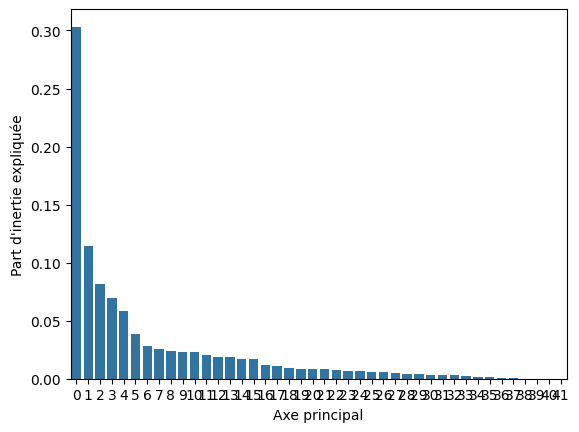

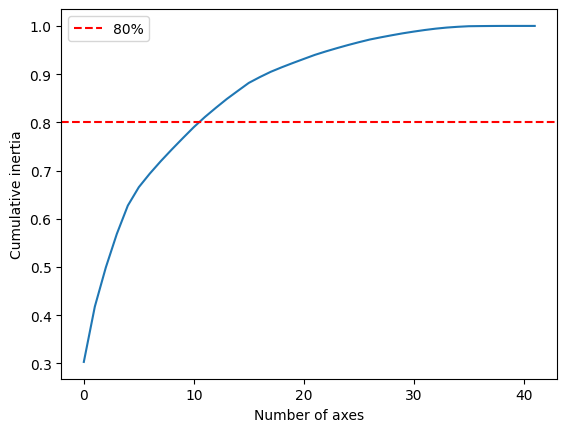

In [7]:
pca_post_pistol = PCA()
Z_post_pistol = pca_post_pistol.fit_transform(df_post_pistol_acp_scaled)

print("Valeurs propres        :", pca_post_pistol.explained_variance_)
print("Explained inertia per axis:", pca_post_pistol.explained_variance_ratio_)

sns.barplot(x=list(range(len(pca_post_pistol.explained_variance_ratio_))),
            y=pca_post_pistol.explained_variance_ratio_)
plt.xlabel("Axe principal")
plt.ylabel("Part d'inertie expliquée")
plt.savefig('../report/figures/post_pistol_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

plt.plot(np.cumsum(pca_post_pistol.explained_variance_ratio_))
plt.axhline(0.8, color='red', linestyle='--', label='80%')
plt.xlabel("Number of axes")
plt.ylabel("Cumulative inertia")
plt.legend()
plt.savefig('../report/figures/post_pistol_pca_cumulated.png', dpi=150, bbox_inches='tight')
plt.show()


### 1.2.3 Choosing the number of axes

In [8]:
cum_var = np.cumsum(pca_post_pistol.explained_variance_ratio_)
n_for_80 = int(np.argmax(cum_var >= 0.80) + 1)

print(f"{n_for_80} axes needed to reach 80 % cumulative inertia.")
print(f"Cumulative inertia at 6 axes: {cum_var[5]*100:.1f} %")
print(f"Cumulative inertia at {n_for_80} axes: {cum_var[n_for_80-1]*100:.1f} %")


12 axes needed to reach 80 % cumulative inertia.
Cumulative inertia at 6 axes: 66.6 %
Cumulative inertia at 12 axes: 81.1 %


### 1.3 Normal

### 1.3.1 Build the input dataframe

In [9]:
df_normal_acp = df_normal_delta.drop(columns=['round_winner', 'map_name'], errors='ignore')
feature_names_normal = list(df_normal_acp.columns)

scaler = StandardScaler()
df_normal_acp_scaled = scaler.fit_transform(df_normal_acp)

print(f"df_normal_acp : {df_normal_acp.shape}")


df_normal_acp : (26322, 43)


### 1.3.2 Scree plot and cumulative inertia

Explained inertia per axis: [2.61937550e-01 1.48765660e-01 7.73686524e-02 6.85049301e-02
 4.95953734e-02 4.73142273e-02 3.54409893e-02 2.86199276e-02
 2.75487993e-02 2.25653655e-02 2.15475635e-02 2.00815154e-02
 1.88438434e-02 1.38571522e-02 1.30214906e-02 1.27483923e-02
 1.15832532e-02 1.10008077e-02 1.05155871e-02 1.00817862e-02
 9.53823741e-03 9.07085460e-03 6.97044024e-03 6.72423344e-03
 6.00353016e-03 5.65150973e-03 5.44689459e-03 5.19458606e-03
 4.86600287e-03 4.61566389e-03 4.42526553e-03 3.64003768e-03
 2.79906323e-03 2.68694595e-03 2.65156832e-03 2.45711567e-03
 2.35179238e-03 2.21788281e-03 1.19825471e-03 3.37800967e-04
 1.88982555e-04 2.04706528e-05 5.86672591e-18]


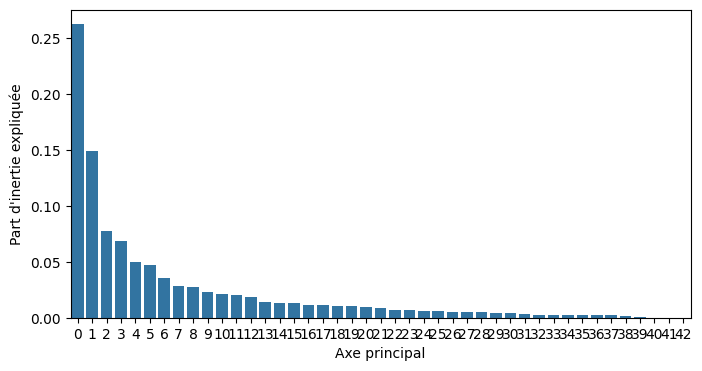

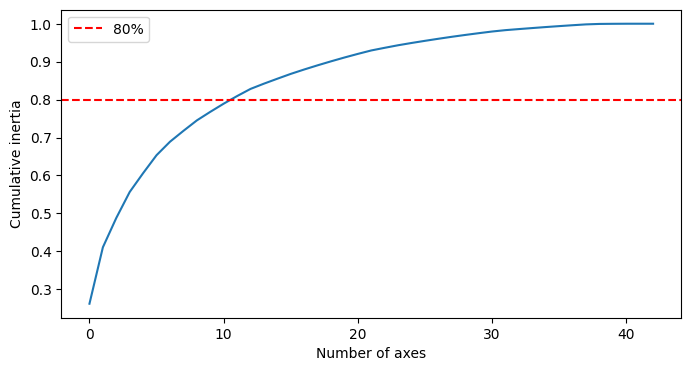

In [10]:
pca_normal = PCA()
Z_normal = pca_normal.fit_transform(df_normal_acp_scaled)

print("Explained inertia per axis:", pca_normal.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=list(range(len(pca_normal.explained_variance_ratio_))),
            y=pca_normal.explained_variance_ratio_, ax=ax)
ax.set_xlabel("Axe principal")
ax.set_ylabel("Part d'inertie expliquée")
fig.savefig('../report/figures/normal_pca_scree.png',
            dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.cumsum(pca_normal.explained_variance_ratio_))
ax.axhline(0.8, color='red', linestyle='--', label='80%')
ax.set_xlabel("Number of axes")
ax.set_ylabel("Cumulative inertia")
ax.legend()
fig.savefig('../report/figures/normal_pca_cumulated.png',
            dpi=150, bbox_inches='tight')
plt.show()


### 1.3.3 Choosing the number of axes

In [11]:
cum_var = np.cumsum(pca_normal.explained_variance_ratio_)
n_for_80 = int(np.argmax(cum_var >= 0.80) + 1)

print(f"{n_for_80} axes needed to reach 80 % cumulative inertia.")
print(f"Cumulative inertia at 6 axes: {cum_var[5]*100:.1f} %")
print(f"Cumulative inertia at {n_for_80} axes: {cum_var[n_for_80-1]*100:.1f} %")


12 axes needed to reach 80 % cumulative inertia.
Cumulative inertia at 6 axes: 65.3 %
Cumulative inertia at 12 axes: 80.9 %


## 2. Logistic Regression

### 2.1 Helper functions

In [12]:
def prepare_df_model(df, df_source=None):
    df_model = df.copy()

    meta_cols = [
        "match_date",
        "tournament",
        "ct_team_name",
        "t_team_name",
        "map_name",
    ]

    if df_source is not None:
        missing_meta_cols = [col for col in meta_cols if col not in df_model.columns]
        df_model[missing_meta_cols] = df_source.loc[df_model.index, missing_meta_cols]

    team_pair = df_model[["ct_team_name", "t_team_name"]].apply(
        lambda row: "_vs_".join(sorted([str(row["ct_team_name"]), str(row["t_team_name"])])),
        axis=1
    )

    df_model["match_key"] = (
        df_model["match_date"].astype(str) + "_" +
        df_model["tournament"].astype(str) + "_" +
        team_pair + "_" +
        df_model["map_name"].astype(str)
    )

    df_model = pd.get_dummies(
        df_model,
        columns=["map_name"],
        prefix="map",
        dtype=int
    )

    return df_model


In [13]:
def split_model_df(df_model, target="round_winner", test_size=0.2):
    match_dates = (
        df_model.groupby("match_key")["match_date"]
        .first()
        .sort_values()
    )

    n_test = int(len(match_dates) * test_size)
    test_matches  = match_dates.iloc[-n_test:].index
    train_matches = match_dates.iloc[:-n_test].index

    train_df = df_model[df_model["match_key"].isin(train_matches)].copy()
    test_df  = df_model[df_model["match_key"].isin(test_matches)].copy()

    y_train = train_df[target].copy()
    y_test  = test_df[target].copy()

    return train_df, test_df, y_train, y_test


In [14]:
def scale_features(train_df, test_df, features):
    X_train = train_df[features].copy()
    X_test = test_df[features].copy()

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, scaler


In [15]:
def evaluate_logreg(model_name, X_train, X_test, y_train, y_test):
    model = LogisticRegression(max_iter=2000)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_test,y_pred),
        "auc": roc_auc_score(y_test, y_proba),
    }

    return model, result

def evaluate_baseline(model_name, y_train, y_test, strategy="most_frequent"):
    X_dummy_train = np.zeros((len(y_train), 1))
    X_dummy_test  = np.zeros((len(y_test), 1))

    model = DummyClassifier(strategy=strategy, random_state=42)
    model.fit(X_dummy_train, y_train)

    y_pred  = model.predict(X_dummy_test)
    y_proba = model.predict_proba(X_dummy_test)[:, 1]

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_proba),
    }

    return model, result


### 2.2 Normal

In [16]:
normal_delta_model_df = prepare_df_model(
    df=df_normal_delta,
    df_source=df_normal
)

normal_delta_map_features = [
    col for col in normal_delta_model_df.columns
    if col.startswith("map_")
]

normal_delta_features_A = [
    "delta_equipment_value",
    "delta_money_total",
    "delta_utility_value",
    "delta_armor_count",
    "delta_helmet_count",
    "delta_survivors_previous",
    "delta_equipment_saved_value",

    "delta_rifle_count",
    "delta_awp_count",
    "ct_ak_count",

    "delta_smoke_count",
    "delta_flash_count",
    "delta_molo_count",
    "delta_he_count",

    "round_number",
    "score_diff",
    "delta_rounds_won_streak",
]

normal_delta_hltv_clean_features = [
    "delta_global_30d_rating",
    "delta_global_90d_rating",
    "delta_global_6months_rating",
    "delta_map_30d_rating",
    "delta_map_90d_rating",
    "delta_map_6months_rating",

    "delta_global_30d_adr",
    "delta_global_90d_adr",
    "delta_global_6months_adr",
    "delta_map_30d_adr",
    "delta_map_90d_adr",
    "delta_map_6months_adr",

    "delta_global_30d_fa",
    "delta_global_90d_fa",
    "delta_global_6months_fa",
    "delta_map_30d_fa",
    "delta_map_90d_fa",
    "delta_map_6months_fa",
]

normal_delta_rw_pct_features = [
    "delta_global_30d_rw_pct",
    "delta_global_90d_rw_pct",
    "delta_global_6months_rw_pct",
    "delta_map_30d_rw_pct",
    "delta_map_90d_rw_pct",
    "delta_map_6months_rw_pct",
]

normal_delta_features_B = normal_delta_features_A + normal_delta_hltv_clean_features
normal_delta_features_C = normal_delta_features_B + normal_delta_map_features
normal_delta_features_D = normal_delta_features_B + normal_delta_rw_pct_features + normal_delta_map_features

normal_delta_feature_sets = {
    "A_normal_delta_round_state_only": normal_delta_features_A,
    "B_normal_delta_plus_HLTV_clean": normal_delta_features_B,
    "C_normal_delta_plus_map": normal_delta_features_C,
    "D_normal_delta_plus_rw_pct": normal_delta_features_D,
}

normal_delta_train_df, normal_delta_test_df, normal_delta_y_train, normal_delta_y_test = split_model_df(
    normal_delta_model_df,
    target="round_winner"
)

normal_delta_models = {}
normal_delta_scalers = {}
normal_delta_results = []

_, baseline_result = evaluate_baseline(
    model_name="0_baseline_majority",
    y_train=normal_delta_y_train,
    y_test=normal_delta_y_test,
)
normal_delta_results.append(baseline_result)

for model_name, features in normal_delta_feature_sets.items():
    X_train_scaled, X_test_scaled, scaler = scale_features(
        train_df=normal_delta_train_df,
        test_df=normal_delta_test_df,
        features=features
    )

    model, result = evaluate_logreg(
        model_name=model_name,
        X_train=X_train_scaled,
        X_test=X_test_scaled,
        y_train=normal_delta_y_train,
        y_test=normal_delta_y_test
    )

    normal_delta_models[model_name] = model
    normal_delta_scalers[model_name] = scaler
    normal_delta_results.append(result)

normal_delta_results_df = (
    pd.DataFrame(normal_delta_results)
    .sort_values("auc", ascending=False)
    .reset_index(drop=True)
)

normal_delta_results_df


,model,accuracy,auc
0,C_normal_delta_plus_map,0.625930,0.691689
1,D_normal_delta_plus_rw_pct,0.624814,0.689810
2,B_normal_delta_plus_HLTV_clean,0.625372,0.688923
3,A_normal_delta_round_state_only,0.618118,0.681527
4,0_baseline_majority,0.544829,0.500000


### 2.3 Pistol

In [17]:
pistol_delta_model_df = prepare_df_model(
    df=df_pistol_delta,
    df_source=df_pistol
)

pistol_delta_map_features = [
    col for col in pistol_delta_model_df.columns
    if col.startswith("map_")
]

pistol_delta_features_A = [
    "delta_equipment_value",
    "delta_utility_value",
    "delta_armor_count",
    "ct_defuser_count",

    "delta_smoke_count",
    "delta_flash_count",
    "delta_molo_count",
    "delta_he_count",

    "round_number",
    "score_diff",
]

pistol_delta_hltv_clean_features = [
    "delta_global_30d_rating",
    "delta_global_90d_rating",
    "delta_global_6months_rating",
    "delta_map_30d_rating",
    "delta_map_90d_rating",
    "delta_map_6months_rating",

    "delta_global_30d_fa",
    "delta_global_90d_fa",
    "delta_global_6months_fa",
    "delta_map_30d_fa",
    "delta_map_90d_fa",
    "delta_map_6months_fa",
]

pistol_delta_win_pct_features = [
    "delta_global_30d_pistol_win_pct",
    "delta_global_90d_pistol_win_pct",
    "delta_global_6months_pistol_win_pct",
    "delta_map_30d_pistol_win_pct",
    "delta_map_90d_pistol_win_pct",
    "delta_map_6months_pistol_win_pct",
]

pistol_delta_features_B = pistol_delta_features_A + pistol_delta_hltv_clean_features
pistol_delta_features_C = pistol_delta_features_B + pistol_delta_map_features
pistol_delta_features_D = pistol_delta_features_B + pistol_delta_win_pct_features + pistol_delta_map_features

pistol_delta_feature_sets = {
    "A_pistol_delta_round_state_only": pistol_delta_features_A,
    "B_pistol_delta_plus_HLTV_clean": pistol_delta_features_B,
    "C_pistol_delta_plus_map": pistol_delta_features_C,
    "D_pistol_delta_plus_pistol_win_pct": pistol_delta_features_D,
}

pistol_delta_train_df, pistol_delta_test_df, pistol_delta_y_train, pistol_delta_y_test = split_model_df(
    pistol_delta_model_df,
    target="round_winner"
)

pistol_delta_models = {}
pistol_delta_scalers = {}
pistol_delta_results = []

_, baseline_result = evaluate_baseline(
    model_name="0_baseline_majority",
    y_train=pistol_delta_y_train,
    y_test=pistol_delta_y_test,
)
pistol_delta_results.append(baseline_result)

for model_name, features in pistol_delta_feature_sets.items():
    X_train_scaled, X_test_scaled, scaler = scale_features(
        train_df=pistol_delta_train_df,
        test_df=pistol_delta_test_df,
        features=features
    )

    model, result = evaluate_logreg(
        model_name=model_name,
        X_train=X_train_scaled,
        X_test=X_test_scaled,
        y_train=pistol_delta_y_train,
        y_test=pistol_delta_y_test
    )

    pistol_delta_models[model_name] = model
    pistol_delta_scalers[model_name] = scaler
    pistol_delta_results.append(result)

pistol_delta_results_df = (
    pd.DataFrame(pistol_delta_results)
    .sort_values("auc", ascending=False)
    .reset_index(drop=True)
)

pistol_delta_results_df


,model,accuracy,auc
0,A_pistol_delta_round_state_only,0.512521,0.531545
1,B_pistol_delta_plus_HLTV_clean,0.509182,0.520759
2,C_pistol_delta_plus_map,0.495826,0.512509
3,D_pistol_delta_plus_pistol_win_pct,0.507513,0.503244
4,0_baseline_majority,0.502504,0.500000


### 2.4 Post-pistol

In [18]:
post_pistol_delta_model_df = prepare_df_model(
    df=df_post_pistol_delta,
    df_source=df_post_pistol
)

post_pistol_delta_map_features = [
    col for col in post_pistol_delta_model_df.columns
    if col.startswith("map_")
]

post_pistol_delta_features_A = [
    "delta_equipment_value",
    "delta_money_total",
    "delta_utility_value",
    "delta_armor_count",
    "delta_helmet_count",
    "delta_survivors_previous",
    "delta_equipment_saved_value",

    "delta_rifle_count",
    "delta_awp_count",

    "delta_smoke_count",
    "delta_flash_count",
    "delta_molo_count",
    "delta_he_count",

    "round_number",
    "score_diff",
    "delta_rounds_won_streak",
]

post_pistol_delta_hltv_clean_features = [
    "delta_global_30d_rating",
    "delta_global_90d_rating",
    "delta_global_6months_rating",
    "delta_map_30d_rating",
    "delta_map_90d_rating",
    "delta_map_6months_rating",

    "delta_global_30d_fa",
    "delta_global_90d_fa",
    "delta_global_6months_fa",
    "delta_map_30d_fa",
    "delta_map_90d_fa",
    "delta_map_6months_fa",
]

post_pistol_delta_round2_features = [
    "delta_global_30d_round2_conv",
    "delta_global_90d_round2_conv",
    "delta_global_6months_round2_conv",
    "delta_map_30d_round2_conv",
    "delta_map_90d_round2_conv",
    "delta_map_6months_round2_conv",

    "delta_global_30d_round2_break",
    "delta_global_90d_round2_break",
    "delta_global_6months_round2_break",
    "delta_map_30d_round2_break",
    "delta_map_90d_round2_break",
    "delta_map_6months_round2_break",
]

post_pistol_delta_features_B = post_pistol_delta_features_A + post_pistol_delta_hltv_clean_features
post_pistol_delta_features_C = post_pistol_delta_features_B + post_pistol_delta_map_features
post_pistol_delta_features_D = post_pistol_delta_features_B + post_pistol_delta_round2_features + post_pistol_delta_map_features

post_pistol_delta_feature_sets = {
    "A_post_pistol_delta_round_state_only": post_pistol_delta_features_A,
    "B_post_pistol_delta_plus_HLTV_clean": post_pistol_delta_features_B,
    "C_post_pistol_delta_plus_map": post_pistol_delta_features_C,
    "D_post_pistol_delta_plus_round2_features": post_pistol_delta_features_D,
}

post_pistol_delta_train_df, post_pistol_delta_test_df, post_pistol_delta_y_train, post_pistol_delta_y_test = split_model_df(
    post_pistol_delta_model_df,
    target="round_winner"
)

post_pistol_delta_models = {}
post_pistol_delta_scalers = {}
post_pistol_delta_results = []

_, baseline_result = evaluate_baseline(
    model_name="0_baseline_majority",
    y_train=post_pistol_delta_y_train,
    y_test=post_pistol_delta_y_test,
)
post_pistol_delta_results.append(baseline_result)

for model_name, features in post_pistol_delta_feature_sets.items():
    X_train_scaled, X_test_scaled, scaler = scale_features(
        train_df=post_pistol_delta_train_df,
        test_df=post_pistol_delta_test_df,
        features=features
    )

    model, result = evaluate_logreg(
        model_name=model_name,
        X_train=X_train_scaled,
        X_test=X_test_scaled,
        y_train=post_pistol_delta_y_train,
        y_test=post_pistol_delta_y_test
    )

    post_pistol_delta_models[model_name] = model
    post_pistol_delta_scalers[model_name] = scaler
    post_pistol_delta_results.append(result)

post_pistol_delta_results_df = (
    pd.DataFrame(post_pistol_delta_results)
    .sort_values("auc", ascending=False)
    .reset_index(drop=True)
)

post_pistol_delta_results_df


,model,accuracy,auc
0,D_post_pistol_delta_plus_round2_features,0.803661,0.862929
1,C_post_pistol_delta_plus_map,0.800333,0.859919
2,B_post_pistol_delta_plus_HLTV_clean,0.801997,0.858353
3,A_post_pistol_delta_round_state_only,0.801997,0.858185
4,0_baseline_majority,0.550749,0.500000
